# Shared response model (SRM) analyses
**Contributors: BrainIAK tutorial code (https://brainiak.org/tutorials/11-SRM/) adapted by James Antony.**  

## Goals
1. Optimize SRM parameters (# dimensions) on independent stimulus (other Friends clip)
2. Apply SRM to original fMRI data for running greedy state boundary search (GSBS)

## Inputs
1. Event information for other Friends stimulus (friendsSRMStoryboard.xlsx)
2. fMRI data from 'view' and 'srm' runs

## Outputs
1. SRM-ified fMRI data from 'view' run in optimal # dimensions (based on SRM stimulus)

In [30]:
ROIs=['V1','vmPFC','ang','PMC','postHC','antHC'] 
ROIs=['antHC']
gp=1
nbr=len(ROIs)
subs=['01','02','03','04','05','06','07','08','09','10','11','12',
      '13','14','15','16','19','20','21','23','24','25','26']
nS=len(subs)
n_trunc=0 # # volumes to truncate
smoothshift=0 #shift from 0?
smoothf=1 #smoothing factor (TRs)
all_task_names = ['view','srm']
run3d=0 #if we want to enforce 3 dim for plotting

import os 
import sys 
import time
import math
import glob
import copy
import scipy
import os.path
import warnings
import datetime
import scipy.io
import matplotlib
import numpy as np
import pandas as pd 
from os import path
import numpy.ma as ma
import nibabel as nib
import numpy.ma as ma
from scipy import stats
from copy import deepcopy
from nilearn import image
from brainiak.isc import isc
from nilearn import datasets
from nilearn import plotting
import brainiak.funcalign.srm
import matplotlib.pyplot as plt
from statesegmentation import GSBS
import matplotlib.patches as patches
from nilearn.image import resample_to_img
import scipy.spatial.distance as sp_distance
from scipy.stats import norm, zscore, pearsonr
from brainiak.fcma.util import compute_correlation
from nilearn.maskers import NiftiMasker, NiftiLabelsMasker
if not sys.warnoptions:
    warnings.simplefilter("ignore")

startt=time.perf_counter()/60
fs,cfs=10,24 #defaults
plt.rcParams.update({'font.size': cfs})
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
cm,cm2,fs0,fs1,fs2='gray','viridis',13,10,10 #colormap styles and fig sizes
figf="figs/"

%autosave 5
%matplotlib inline

Autosaving every 5 seconds


In [31]:
#preset variables
import fr_utils
from fr_utils import load_fr_epi_data, load_fr_mask, mask_data, load_data
from fr_utils import fr_dir, fr_bids_dir, fr_TR, fr_hrf_lag, run_names
analysis_dir=fr_dir+'analysis/'
fn=analysis_dir+'lum_mot_all_SRM.mat'
mat_contents = scipy.io.loadmat(fn)
mot_tc = mat_contents['mot_tr']
mot_tc_thr = mat_contents['mot_tr_thr']
fn=analysis_dir+'upperAud_tr_SRM.mat'
mat_contents = scipy.io.loadmat(fn)
aud_tc = mat_contents['upper_tr']

#functions
lw9=2
def findsecs(tstring): #find absolute # of seconds, based on HMS input
    date_time = datetime.datetime.strptime(tstring, "%H:%M:%S")
    a_timedelta = date_time - datetime.datetime(1900, 1, 1)
    seconds = a_timedelta.total_seconds()
    return seconds

def plot_tt_similarity_matrix(ax, data_matrix, bounds, sec_bounds,bounds_true, npts):
    twodmat=fishr2z2d(data_matrix.T)
    im=ax.imshow(twodmat, cmap='viridis',vmin=-0.9,vmax=0.9)
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(lw9)
    # plot predicted boundaries 
    if len(bounds)>0:
        bounds_aug = np.concatenate(([0],bounds,[npts]))
        for i in range(len(bounds_aug)-1):
            rect = patches.Rectangle(
                (bounds_aug[i]-0.5,bounds_aug[i]-0.5),
                bounds_aug[i+1]-bounds_aug[i],
                bounds_aug[i+1]-bounds_aug[i],
                linewidth=lw9,edgecolor='w',facecolor='none')
            ax.add_patch(rect)
    if len(sec_bounds)>0:
        bounds_aug = np.concatenate(([0],sec_bounds,[npts]))
        for i in range(len(bounds_aug)-1):
            rect = patches.Rectangle(
                (bounds_aug[i],bounds_aug[i]),
                bounds_aug[i+1]-bounds_aug[i],
                bounds_aug[i+1]-bounds_aug[i],
                linewidth=lw9,edgecolor='y',facecolor='none')
            ax.add_patch(rect)
    if len(bounds_true)>0:
        bounds_aug = np.concatenate(([0],bounds_true,[npts]))
        for i in range(len(bounds_aug)-1):
            rect = patches.Rectangle(
                (bounds_aug[i],bounds_aug[i]),
                bounds_aug[i+1]-bounds_aug[i],
                bounds_aug[i+1]-bounds_aug[i],
                linewidth=lw9,edgecolor='r',facecolor='none')
            ax.add_patch(rect)
    return twodmat,im

#function for similarity matrix
def fishr2z2d(dat):
    rs=np.corrcoef(dat)
    for m in range(rs.shape[0]): #r-to-z transform
        for n in range(rs.shape[0]):
            rs[m,n]=np.multiply((np.log([1+rs[m,n]])-np.log([1-rs[m,n]])),0.5)
            if m==n:
                rs[m,n]=0 #blank out diagonal
    return rs

def running_max(x, N):
    rm=np.zeros((x.shape[0]))
    for i in range(len(x)):
        if i<N:
            rm[i]=np.max(x[0:i+N+1])#max
        elif i>len(x)-1-N:
            rm[i]=np.max(x[i-N:len(x)-1+1])
        else:
            rm[i]=np.max(x[i-N:i+N+1])
    return rm

def running_mean(x,N,shift):
    rm=np.zeros((x.shape[0]))
    for i in range(0,len(x)):
        if i<N+shift:
            rm[i]=np.mean(x[0:(i+N)+shift+1])
        elif i>len(x)-1-N+shift:
            rm[i]=np.mean(x[(i)+shift:len(x)-1+1]) #smooth only forward
        else:
            #rm[i]=np.mean(x[(i-N)+shift:(i+N)+shift+1])
            rm[i]=np.mean(x[(i)+shift:(i+N)+shift+1]) #smooth only forward
    return rm

All changes (in TR): [ 17  43  76 121 176 191 201 220 235 254 273 291 307]
All scene changes (in TR): [ 76 121 176 201 254 307]
length of timecourse: 343


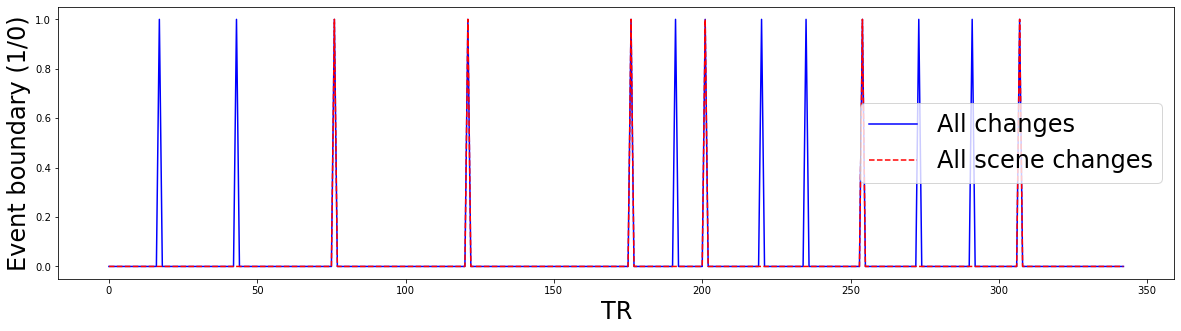

In [32]:
#load SRM events data
df = pd.read_excel('/Users/jamesantony/Desktop/friends_fmri/data/behavioral/friendsSRMStoryBoard.xlsx','FriendsSRMNarr') #read in
df['Secs']="" #pre-assign empty secs column 
for i in range(df.shape[0]):
    df['Secs'][i]=findsecs(str(df['Time'][i]))
cols = df.columns.tolist()
cols = cols[-1:] + cols[:-1]
df = df[cols]
tsecs=np.int(df['Secs'][df.shape[0]-1]) #total seconds
#print(df)
ttrs=np.int(np.floor(tsecs/fr_TR)) #total TRs
qq=df['Secs'][:-1] #find times of possession changes #ignore first time point b/c not boundary!
all_edges=qq[1:].to_numpy()
qqq=np.diff(df['SceneNum'][:-1])
ix=np.where(qqq==1)
all_edges_st=qq[ix[0]+1].to_numpy()
all_edges_tr=all_edges//fr_TR
all_edges_st_tr=all_edges_st//fr_TR
all_edges_tr,all_edges_st_tr=all_edges_tr.astype(int),all_edges_st_tr.astype(int)
print('All changes (in TR): %s' %all_edges_tr)
print('All scene changes (in TR): %s' %all_edges_st_tr)

all_edges_tc_tr,all_edges_st_tc_tr=np.zeros((ttrs)),np.zeros((ttrs))
all_edges_tc_tr[all_edges_tr]=1
all_edges_st_tc_tr[all_edges_st_tr]=1

f, ax = plt.subplots(1,1,figsize = (fs1*2,fs2/2)) #for instance
ax.plot(all_edges_tc_tr,'b')
ax.plot(all_edges_st_tc_tr,'--r')
ax.set_xlabel('TR',fontsize=cfs)
ax.set_ylabel('Event boundary (1/0)',fontsize=cfs)
ax.legend(['All changes','All scene changes'],fontsize=cfs)
print('length of timecourse: %s' %all_edges_tc_tr.shape)
fn="figs/SRM_events.pdf"
plt.savefig(fn, transparent=True)

ROI #: 0
filename: pydata/srm-antHC.npy
ROI: antHC
# features: 5


100it [00:22,  4.40it/s]                                                                              


# features: 6


100it [00:22,  4.35it/s]                                                                              


# features: 7


...

# features: 39


100%|█████████████████████████████████████████████████████████████████| 99/99 [00:26<00:00,  3.78it/s]


# features: 40


100%|█████████████████████████████████████████████████████████████████| 99/99 [00:26<00:00,  3.75it/s]


5
Fitting SRM using 5 features, may take a minute ...
SRM has been fit
SRM: Features X Time-points  (5, 326)


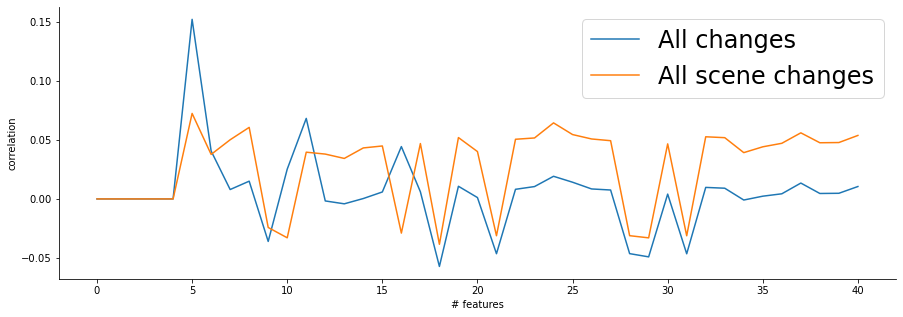

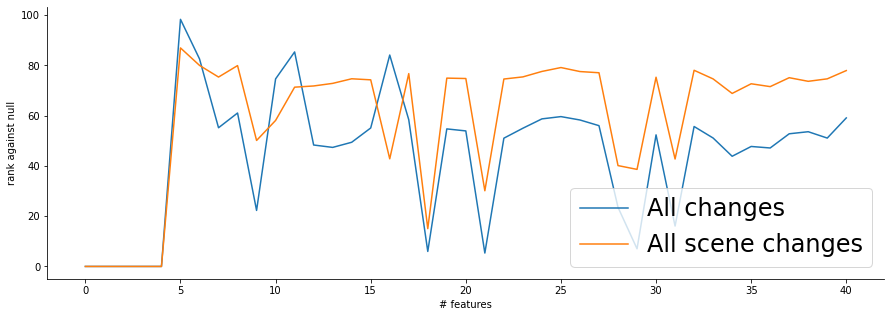

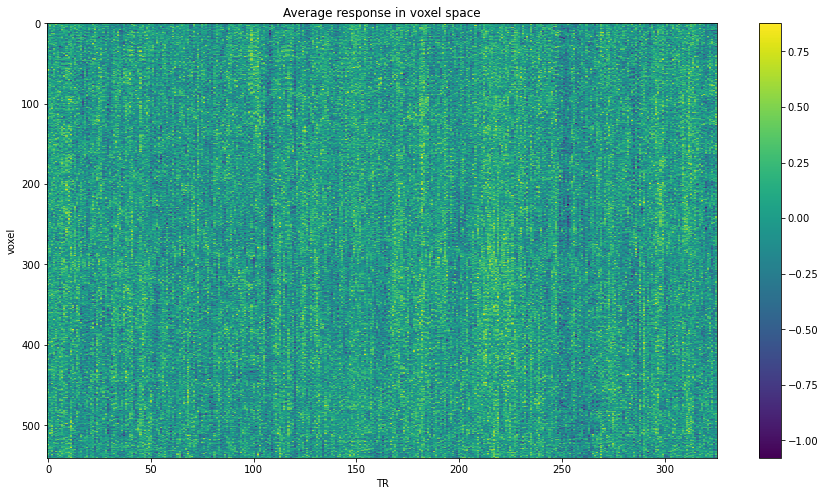

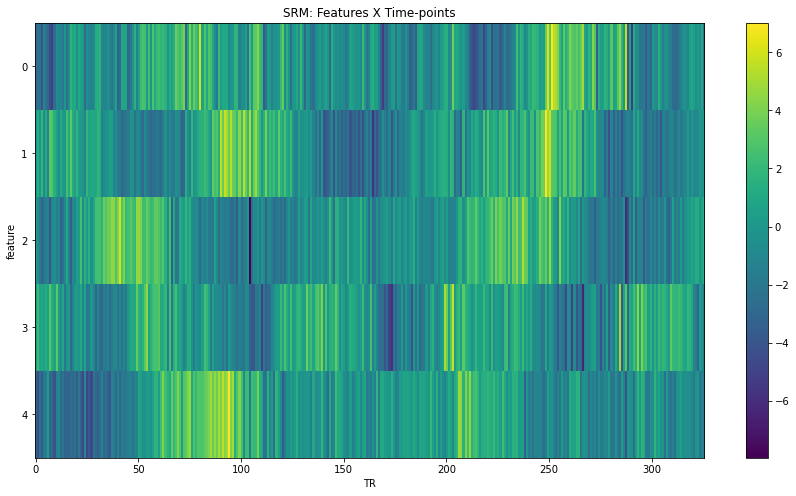

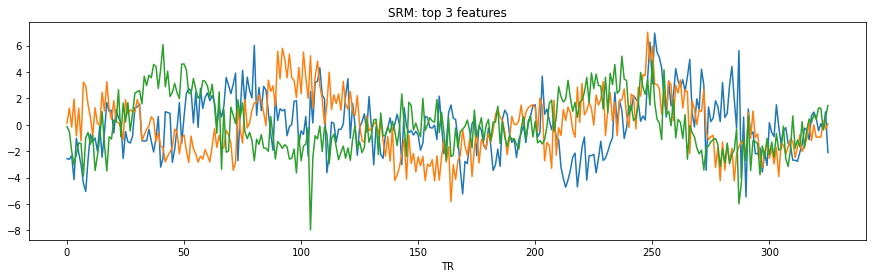

Mean raw r: 0.015718714276223313 , shared r: 0.002737677181988116
Independent samples t test between raw and SRM transformed data: -2.0129277893515787 p: 0.04461439011929621
pydata/view-1-antHC_postSRM_10.npy
(1263, 5, 23)
antHC script took 21.32226629901669 minutes.


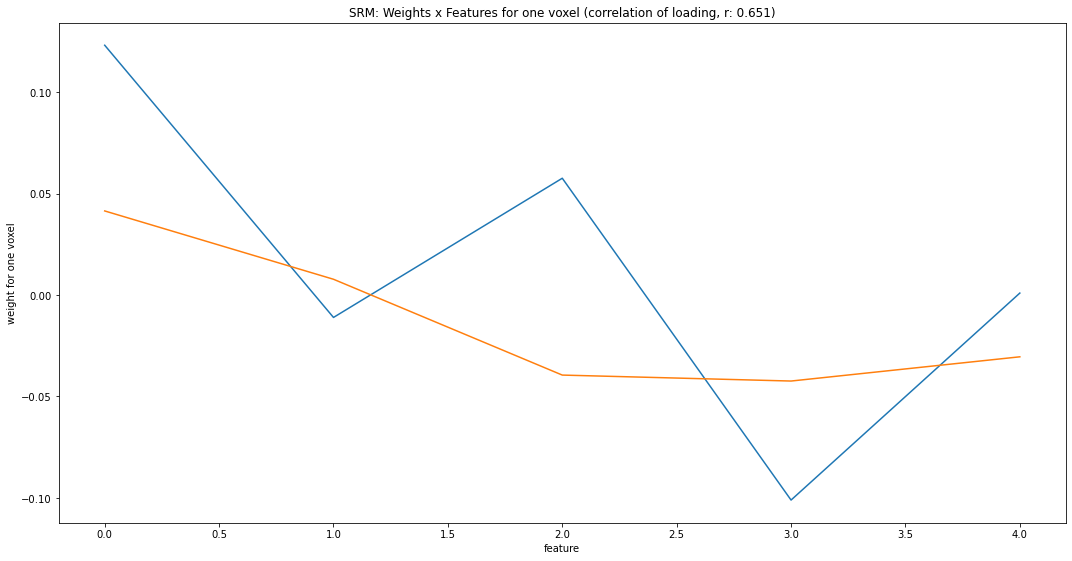

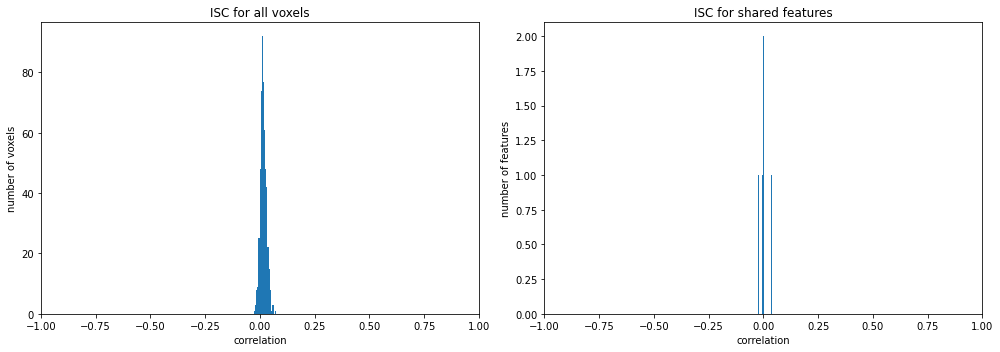

In [33]:
#large loop over which we find best # of dimensions

#set up experiment metadata
fr_TR=2
if gp==4:
    nbr=100
    whichp=2
    dataset=datasets.fetch_atlas_schaefer_2018(n_rois=nbr,resolution_mm=2)
    ROIs=dataset.labels
    i=np.eye(3)*2 
    dataset.maps=image.resample_img(dataset.maps, target_affine=i,interpolation='nearest') #resample
    
    plotting.plot_roi(dataset.maps, title='parcels') #quick parcels plot
    masker_ho=NiftiLabelsMasker(labels_img=dataset.maps) #parcel labels
    index=masker_ho.labels_img.dataobj
    ROIs=dataset.labels
    
#x-validate features and use best fit to TEST data
maxf=40  #max # SRM features
maxk=100 #max # GSBS states
ploty,plotyy=0,1 #make looped / final plots

for roin in range(nbr): #JWA 8/2/25
    print('ROI #:',roin)
    if gp==4:
        for s in range(nS):
            fn='pydata/'+all_task_names[1]+'-all-'+str(subs[s])+'-'+str(whichp)+'.npy'
            zz=np.load(fn,allow_pickle=True)
            bold_roi=zz[roin].T 
            if s==0:
                movie_data=np.zeros((bold_roi.shape[1],bold_roi.shape[0],nS))
            movie_data[:,:,s]=bold_roi.T

            fn='pydata/'+all_task_names[0]+'-all-'+str(subs[s])+'-'+str(whichp)+'.npy'
            zz=np.load(fn,allow_pickle=True)
            bold_roi=zz[roin].T 
            if s==0:
                md2=np.zeros((bold_roi.shape[1],bold_roi.shape[0],nS))
            md2[:,:,s]=bold_roi.T

    elif gp==1:
        sn='pydata/srm-' + ROIs[roin] + '.npy'
        print('filename:',sn)
        movie_data=np.load(sn)
        print('ROI:', ROIs[roin]) #voxels x TRs x subjects
        sn='pydata/view-' + ROIs[roin] + '.npy'
        md2=np.load(sn)

    # Pull out the shape data
    vox_num2, nTR2, num_subs2 = md2.shape  
    #print('Vox x TRs x Subs, view:', md2.shape) #voxels x TRs x subjects
    
    #cut TRs from beginning and end? - this makes SRM training work better
    all_edges_tc_tr,all_edges_st_tc_tr=np.zeros((ttrs)),np.zeros((ttrs))
    all_edges_tc_tr[all_edges_tr]=1
    all_edges_st_tc_tr[all_edges_st_tr]=1
    scut,ecut=10,10 #changed from 15,10 #20,25
    if scut+ecut>0:
        movie_data=movie_data[:,scut:-ecut,:]
        all_edges_tc_tr,all_edges_st_tc_tr=all_edges_tc_tr[scut:-ecut],all_edges_st_tc_tr[scut:-ecut]

    # Pull out the shape data
    vox_num, nTR, num_subs = movie_data.shape  
    #print('Data, SRM:', movie_data[:2,:2,:2]) #voxels x TRs x subjects
    #print('Vox x TRs x Subs, SRM:', movie_data.shape) #voxels x TRs x subjects

    train_data = []
    test_data = []
    for sub in range(num_subs):
        splittr=nTR
        train_data.append(movie_data[:,:, sub]) 
        test_data.append(md2[:,:, sub])
    # Iterate through the subjects
    for sub in range(num_subs):    
        train_data[sub] = stats.zscore(train_data[sub], axis=1, ddof=1) #train data
        train_data[sub] = np.nan_to_num(train_data[sub])
        test_data[sub] = stats.zscore(test_data[sub], axis=1, ddof=1) #test data
        test_data[sub] = np.nan_to_num(test_data[sub])
     
    #before putting in loop, figure out logic of SRM - GSBS w/ set # features
    divf=1 #do >1 if we wanted to skip over features
    feat_a=np.linspace(0,maxf,int(maxf/divf)+1) # How many features will you fit?
    n_iter=100  # How many iterations of fitting will you perform
    xval_r=np.zeros((len(feat_a)))
    smooth_agree_rs,smooth_st_agree_rs=np.zeros(len(feat_a)),np.zeros(len(feat_a))
    smooth_agree_ranks,smooth_st_agree_ranks=np.zeros(len(feat_a)),np.zeros(len(feat_a))
    #JWA 8/2/25 was running (5,len(feat_a)) -- do 'for i in range(3,4):' once to plot 3-D in embedding space
    for i in range(5,len(feat_a)): 
        features=int(feat_a[i])
        print('# features:',features)
        if features!=1:
            if features==0: #train on raw data
                raw_obj = np.zeros((train_data[0].shape[1], train_data[0].shape[0], len(train_data))) #flipped from tutorial
                for ppt in range(len(train_data)): # Reorganize the data into an appropriate space for ISC
                    raw_obj[:, :, ppt] = train_data[ppt].T
                corr_raw = isc(raw_obj, summary_statistic='mean') # Perform ISC
                corr_raw = np.nan_to_num(corr_raw) 
            else:
                srm = brainiak.funcalign.srm.SRM(n_iter=n_iter, features=features) #create SRM object
                srm.fit(train_data) #fit SRM

                shared_train = srm.transform(train_data) # Transform the SRM data into shared spac
                for subject in range(num_subs): # Zscore the transformed training data
                    shared_train[subject] = stats.zscore(shared_train[subject], axis=1, ddof=1)
                shared_obj = np.zeros((shared_train[0].shape[1], shared_train[0].shape[0], len(train_data))) #flip
                for ppt in range(len(train_data)): # Reorganize SRM-transformed data into an appropriate space for ISC
                    shared_obj[:, :, ppt] = shared_train[ppt].T
                #print('shared_obj shape:',shared_obj.shape)
                corr_shared = isc(shared_obj, summary_statistic='mean') # Perform ISC
                corr_shared = np.nan_to_num(corr_shared)

            start_feat,end_feat=0,features#//2
            if features==0:
                mm=np.mean(raw_obj,axis=2)
                T=raw_obj.shape[0]
            else:
                mm=np.mean(shared_obj[:,start_feat:end_feat,:],axis=2)
                T=shared_obj.shape[0]
            t1=time.perf_counter()/60
            #print('Testing up to %s states' %maxk)
            GSBS_states = GSBS(x = mm, kmax = maxk)
            GSBS_states.fit()
            t2=time.perf_counter()/60
            #print('GSBS took %s minutes.' %(t2-t1))
            #print('The optimal number of events is ' + str(GSBS_states.nstates))
            best_s=np.max(GSBS_states.nstates)

            if ploty:
                f, ax = plt.subplots(1,1, figsize = (10,3))
                plt.plot(GSBS_states.tdists[:-1])
                plt.xlabel('Number of events')
                plt.ylabel('T-distance')
                plt.plot(GSBS_states.nstates, GSBS_states.tdists[GSBS_states.nstates], 'ro', label= 'optimal number of events')
                plt.legend()
                fn="figs/SRM_GSBS_Tdist-"+str(gp)+"-"+str(ROIs[roin])+"-"+str(features)+".pdf"
                plt.savefig(fn, transparent=True)

            GSBS_bounds = np.where(GSBS_states.deltas)[0]
            best_s=np.max(GSBS_states.nstates) #best-fitting # of states
            GSBS_bounds_by_tr = np.where(GSBS_states.get_deltas(best_s))[0] #gives location of boundaries for given # states
            GSBS_bounds_by_sec=GSBS_bounds_by_tr*2
            GSBS_bound_tc=np.zeros((T))
            GSBS_bound_tc[GSBS_bounds_by_tr]=GSBS_states.strengths[GSBS_bounds_by_tr] #weight by strength of boundary!
            #GSBS_bound_tc[GSBS_bounds_by_tr]=1 #

            pts=T
            if ploty:
                f, ax = plt.subplots(1,1, figsize = (15,15))
                exmat,im=plot_tt_similarity_matrix(ax, mm[:pts,:pts].T, 
                                                   np.divide(all_edges,fr_TR),[],GSBS_bounds_by_tr, T)
                f.tight_layout()
                title_text = '''TR-TR correlation matrix'''
                ax.set_title(title_text)
                f.colorbar(im, orientation='vertical')
                fn="figs/SRM_GSBS_simmat-"+str(gp)+"-"+str(ROIs[roin])+"-"+str(features)+".pdf"
                plt.savefig(fn, transparent=True)

            if i==0:
                print('length of fmri timecourse in TR: %s' %GSBS_bound_tc.shape)
                print('length of video timecourse in TR: %s' %all_edges_tc_tr.shape)
            #print('# identified boundaries: %s' %GSBS_bounds_by_tr.shape)
            lmt,nb,j=5,len(GSBS_bounds_by_tr),0
            rge=np.linspace(-lmt,lmt,lmt*2+1)

            dat=np.zeros((len(all_edges_tr),len(rge)))
            quicktest=2
            if quicktest==1:
                qt=mot_tc_thr[:,0]
            elif quicktest==2:
                qt=copy.deepcopy(all_edges_tc_tr)
            for ii in range(len(all_edges_tr)):
                #curr=GSBS_bounds_by_tr[ii]
                curr=all_edges_tr[ii]
                if np.logical_and(curr>=lmt,curr<len(GSBS_bound_tc)-lmt+1):
                    dat[j,:]=GSBS_bound_tc[curr-lmt:curr+lmt+1]
                    j+=1
            
            x,y,err=rge,np.sum(dat,axis=0),np.std(dat,axis=0)
            if ploty:
                f,ax = plt.subplots(1,1, figsize = (10,3))
                ax.errorbar(rge,np.sum(dat,axis=0),np.std(dat,axis=0)/np.sqrt(nb))
                ax.set_xlabel('Time (relative to GSBS boundary)')
                if quicktest==1:
                    ax.set_ylabel('''Global motion moments
above threshold''')
                elif quicktest==2:
                    ax.set_ylabel('''Event boundaries''')

            bounds_smooth_tc=running_mean(GSBS_bound_tc,smoothf,smoothshift)
            
            minl=all_edges_tc_tr.shape[0]
            agree_r=ma.corrcoef(ma.masked_invalid(GSBS_bound_tc[:minl]), ma.masked_invalid(all_edges_tc_tr[:minl]))[1,0]
            
            fill=ma.corrcoef(ma.masked_invalid(GSBS_bound_tc[:minl]), ma.masked_invalid(all_edges_st_tc_tr[:minl]))
            st_agree_r=fill[1,0] #smoothed correlation
            
            fill=ma.corrcoef(ma.masked_invalid(bounds_smooth_tc[:minl]), ma.masked_invalid(all_edges_tc_tr[:minl]))
            smooth_agree_r=fill[1,0] #smoothed correlation
           
            fill=ma.corrcoef(ma.masked_invalid(bounds_smooth_tc[:minl]), ma.masked_invalid(all_edges_st_tc_tr[:minl]))
            smooth_st_agree_r=fill[1,0] #smoothed correlation
            
            smooth_agree_rs[i]=smooth_agree_r
            smooth_st_agree_rs[i]=smooth_st_agree_r

            nperms=10000
            agree_s_r,agree_st_s_r=np.zeros((nperms)),np.zeros((nperms))
            for ii in range(nperms):
                qq=np.random.permutation(minl)
                tc_s=all_edges_tc_tr[qq] #could also use mot_tc
                fill=ma.corrcoef(ma.masked_invalid(bounds_smooth_tc[:minl]), ma.masked_invalid(tc_s[:minl]))
                agree_s_r[ii]=fill[1,0] #smoothed correlation
                tc_s=all_edges_st_tc_tr[qq] #could also use mot_tc
                fill=ma.corrcoef(ma.masked_invalid(bounds_smooth_tc[:minl]), ma.masked_invalid(tc_s[:minl]))
                agree_st_s_r[ii]=fill[1,0] #smoothed correlation
            smooth_agree_ranks[i]=stats.percentileofscore(agree_s_r,smooth_agree_r)
            smooth_st_agree_ranks[i]=stats.percentileofscore(agree_st_s_r,smooth_st_agree_r)
            
    if plotyy:
        f, ax = plt.subplots(1,1, figsize=(15,5))
        plt.plot(feat_a,smooth_agree_rs)
        plt.plot(feat_a,smooth_st_agree_rs)
        plt.xlabel('# features')
        plt.ylabel('correlation')
        ax.legend(['All changes','All scene changes'],loc='upper right',fontsize=cfs)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False) 
        fn="figs/SRM_GSBS_corrsXfeatures-"+str(gp)+"-"+str(ROIs[roin])+"-"+str(features)+"-"+str(smoothshift)+".pdf"
        plt.savefig(fn, transparent=True)

        f, ax = plt.subplots(1,1, figsize=(15,5))
        plt.plot(feat_a,smooth_agree_ranks)
        plt.plot(feat_a,smooth_st_agree_ranks)
        plt.xlabel('# features')
        plt.ylabel('rank against null')
        ax.legend(['All changes','All scene changes'],loc='lower right',fontsize=cfs)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False) 
        fn="figs/SRM_GSBS_ranksXfeatures-"+str(gp)+"-"+str(ROIs[roin])+"-"+str(features)+"-"+str(smoothshift)+".pdf"
        plt.savefig(fn, transparent=True)

    #print(smooth_agree_ranks)
    if np.logical_and(run3d,i==3):
        qq=i+0
    else:
        #qmax=np.max(smooth_agree_ranks[5:]) #must be >5 features 6/7/26 bug - already accounting for >=5
        qmax=np.max(smooth_agree_ranks) #must be >5 features 
        qq=np.where(smooth_agree_ranks==qmax)[0]
        qq=qq[0] #if tie, choose lower
    #moving forward, use best fit value!
    #features = int(feat_a[qq+1]) #indx  # How many features will you fit?
    features = int(feat_a[qq]) #indx  # How many features will you fit?
    print(features)

    srm = brainiak.funcalign.srm.SRM(n_iter=n_iter, features=features) #create SRM object
    print('Fitting SRM using %s features, may take a minute ...' %features)
    srm.fit(train_data) #fit SRM
    print('SRM has been fit')
    
    dist_mat = sp_distance.squareform(sp_distance.pdist(srm.s_.T))
    
    #plot average response in anatomical space
    if plotyy:
        plt.figure(figsize=(15, 8))
        plt.title('Average response in voxel space')
        plt.xlabel('TR')
        plt.ylabel('voxel')
        plt.imshow(np.mean(movie_data,axis=2), cmap='viridis',interpolation='none',aspect="auto")
        plt.colorbar()

        # Plot the shared response
        print('SRM: Features X Time-points ', srm.s_.shape)
        plt.figure(figsize=(15, 8))
        plt.title('SRM: Features X Time-points')
        plt.xlabel('TR')
        plt.ylabel('feature')
        plt.imshow(srm.s_, cmap='viridis',interpolation='none',aspect="auto")
        plt.colorbar()

        plt.figure(figsize=(15, 4))
        plt.title('SRM: top 3 features')
        plt.xlabel('TR')
        plt.plot(srm.s_[0:3, :].T)
        plt.show()

        plt.figure(figsize=(15,15))
        plt.title('Distance between pairs of time points in shared space')
        plt.xlabel('TR')
        plt.ylabel('TR')
        plt.imshow(dist_mat, cmap='viridis',interpolation='none',aspect="auto")
        plt.colorbar()

        vn=5 #voxel #
        plt.subplot(211)
        plt.plot(srm.w_[0][vn,:])
        plt.plot(srm.w_[1][vn,:])
        feature_corr = np.corrcoef(srm.w_[0][vn,:], srm.w_[1][vn,:].T)[0,1]
        plt.title('SRM: Weights x Features for one voxel (correlation of loading, r: %0.3f)' % feature_corr) 
        plt.xlabel('feature')
        plt.ylabel('weight for one voxel')
        plt.tight_layout()

    # Transform the SRM data into shared space
    shared_train = srm.transform(train_data)

    # Zscore the transformed training data
    for subject in range(num_subs):
        shared_train[subject] = stats.zscore(shared_train[subject], axis=1, ddof=1)

    # Reorganize the data back into an appropriate space for ISC
    raw_obj = np.zeros((train_data[0].shape[1], train_data[0].shape[0], len(train_data))) #flipped from tutorial
    for ppt in range(len(train_data)):
        raw_obj[:, :, ppt] = train_data[ppt].T

    # Perform ISC on all participants, collapsing across participants    
    corr_raw = isc(raw_obj, summary_statistic='mean')
    corr_raw = np.nan_to_num(corr_raw)  

    # Reorganize the SRM transformed data back into an appropriate space for ISC
    shared_obj = np.zeros((shared_train[0].shape[1], shared_train[0].shape[0], len(train_data))) #flip
    for ppt in range(len(train_data)):
        shared_obj[:, :, ppt] = shared_train[ppt].T

    # Perform ISC on all participants, collapsing across participants        
    corr_shared = isc(shared_obj, summary_statistic='mean')
    corr_shared = np.nan_to_num(corr_shared)
    #print(len(train_data))
    #print(raw_obj.shape)
    #print(shared_obj.shape)

    nbins=20
    # Transform the test data into the shared space using the individual weight matrices
    shared_test = srm.transform(test_data)
    # Zscore the transformed test data
    for subject in range(num_subs):
        shared_test[subject] = stats.zscore(shared_test[subject], axis=1, ddof=1)

    # Reorganize the data back into an appropriate space for ISC
    raw_test_obj = np.zeros((test_data[0].shape[1], test_data[0].shape[0], len(test_data))) #flip from tutorial
    for ppt in range(len(test_data)):
        raw_test_obj[:, :, ppt] = test_data[ppt].T

    # Perform ISC on all participants, collapsing across participants    
    corr_test_raw = isc(raw_test_obj, summary_statistic='mean')
    corr_test_raw = np.nan_to_num(corr_test_raw)  
    #print('raw data shape:',raw_test_obj.shape)
    # Reorganize the SRM transformed data back into an appropriate space for ISC
    shared_test_obj = np.zeros((shared_test[0].shape[1], shared_test[0].shape[0], len(test_data)))
    for ppt in range(len(train_data)):
        shared_test_obj[:, :, ppt] = shared_test[ppt].T

    # Perform ISC on all participants, collapsing across participants        
    corr_test_shared = isc(shared_test_obj, summary_statistic='mean')
    corr_test_shared = np.nan_to_num(corr_test_shared)
    #print('shared data shape:',shared_test_obj.shape)

    if plotyy:
        plt.figure(figsize=(14,5))
        plt.subplot(1, 2, 1)
        plt.title('ISC for all voxels')
        plt.hist(corr_test_raw,nbins);
        plt.xlabel('correlation')
        plt.ylabel('number of voxels')
        plt.xlim([-1, 1]);
        plt.subplot(1, 2, 2)
        plt.title('ISC for shared features')
        plt.hist(corr_test_shared,nbins);
        plt.xlabel('correlation')
        plt.ylabel('number of features')
        plt.xlim([-1, 1]);
        plt.tight_layout()

    tstat = stats.ttest_ind(np.arctanh(corr_test_shared), np.arctanh(corr_test_raw))
    print('Mean raw r:', np.mean(corr_test_raw), ', shared r:', np.mean(corr_test_shared))
    print('Independent samples t test between raw and SRM transformed data:', tstat.statistic, 'p:', tstat.pvalue)

    sn='pydata/view-'+str(gp)+'-'+str(ROIs[roin])+'_postSRM_'+str(scut)+'.npy'
    #sn='pydata/view-'+str(gp)+'-'+str(ROIs[roin])+'_postSRM_'+str(scut)+'-3features.npy'
    print(sn)
    np.save(sn,shared_test_obj)
    print(shared_test_obj.shape)

    endt=time.perf_counter()/60
    print('%s script took %s minutes.' %(ROIs[roin],endt-startt))

In [34]:
sn 

'pydata/view-1-antHC_postSRM_10.npy'

notes: 
also separately ran with 3 features only to plot in HD space -- see '8/2/25' for changes

In [35]:
print('SRM: Features X Time-points ', srm.s_.shape)

SRM: Features X Time-points  (5, 326)
